# Fraud Detection Dataset - EDA Charts

Exploratory visualization suite for the 5,000,000-row transaction dataset (45 columns).

**Sections:**
1. When do transactions happen
2. Sender persona with the most fraud
3. Top fraud IP addresses
4. Fraud vs Non-Fraud by transaction_type / payment_channel / device_used
5. Top merchant categories
6. Transaction amount distribution
7. Fraud vs Non-Fraud ratio
8. Location with the most fraud


## 0. Setup & style config

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

In [ ]:
dtype = {
    # category
    "transaction_type": "category",
    "merchant_category": "category",
    "location": "category",
    "device_used": "category",
    "fraud_type": "category",
    "payment_channel": "category",
    "ip_address": "category",
    "sender_persona": "category",
    "user_top_category": "category",
    "ip_geo_region": "category",

    # string
    "transaction_id": "string",
    "device_hash": "string",

    # uint64
    "sender_account": "uint64",
    "receiver_account": "uint64",

    # uint8
    "is_fraud": "uint8",
    "velocity_score": "uint8",
    "bvn_linked": "uint8",
    "new_device_transaction": "uint8",
    "geospatial_velocity_anomaly": "uint8",
    "txn_hour": "uint8",
    "is_weekend": "uint8",
    "is_salary_week": "uint8",
    "is_night_txn": "uint8",
    "device_seen_count": "uint8",
    "is_device_shared": "uint8",
    "is_ip_shared": "uint8",
    "user_txn_count_total": "uint8",
    "user_txn_frequency_24h": "uint8",
    "txn_count_last_1h": "uint8",
    "txn_count_last_24h": "uint8",

    # uint16
    "ip_seen_count": "uint16",

    # float32
    "time_since_last_transaction": "float32",
    "spending_deviation_score": "float32",
    "geo_anomaly_score": "float32",
    "amount_ngn": "float32",
    "user_avg_txn_amt": "float32",
    "user_std_txn_amt": "float32",
    "total_amount_last_1h": "float32",
    "time_since_last": "float32",
    "avg_gap_between_txns": "float32",
    "merchant_fraud_rate": "float32",
    "channel_risk_score": "float32",
    "persona_fraud_risk": "float32",
    "location_fraud_risk": "float32",
}

In [ ]:
df = pd.read_csv(
    'data/recolumns.csv',
    dtype=dtype,
    parse_dates=["timestamp"],
)

In [ ]:
df

,transaction_id,timestamp,sender_account,receiver_account,amount_ngn,sender_persona,location,ip_geo_region,ip_address,ip_seen_count,...,user_avg_txn_amt,user_std_txn_amt,avg_gap_between_txns,txn_hour,spending_deviation_score,velocity_score,geo_anomaly_score,geospatial_velocity_anomaly,is_fraud,fraud_type
0,T2162315,2023-01-24 09:54:06.198396,1000018177,8385560081,654135.062500,Student,Aba,South East,197.210.68.224,21,...,6.541351e+05,0.000000e+00,0.000000,9,-0.36,12,0.98,0,0,NaN
1,T1764581,2023-02-22 16:16:19.271951,1000018177,5643014197,33314.031250,Student,Onitsha,South East,41.58.166.64,36,...,3.437246e+05,4.389868e+05,21071.109375,16,0.07,8,0.71,0,0,NaN
2,T3305551,2023-05-04 16:01:42.312142,1000018177,7722691989,32536.660156,Student,Onitsha,South East,197.210.67.69,19,...,2.399952e+05,3.586558e+05,48122.535156,16,1.95,10,0.56,0,0,NaN
3,T174955,2023-05-07 13:15:03.037215,1000018177,4987435115,13445.110352,Student,Benin City,South South,105.112.143.74,5,...,1.833577e+05,3.139861e+05,37130.238281,13,-1.13,19,0.35,0,0,NaN
4,T3695059,2023-06-08 11:37:39.155188,1000018177,7939643449,125112.562500,Student,Aba,South East,197.210.155.144,19,...,1.717087e+05,2.731647e+05,38900.710938,11,-1.47,9,0.03,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,T2319152,2023-11-23 16:22:20.971217,9999973159,5340639823,583207.312500,Trader,Onitsha,South East,102.89.33.204,288,...,2.226268e+06,3.886392e+06,53822.496094,16,0.04,15,0.25,0,0,NaN
4999996,T2833155,2023-12-25 13:12:33.898607,9999973159,9337859305,644781.125000,Trader,Aba,South East,41.58.225.204,35,...,2.050547e+06,3.673410e+06,52941.132812,13,-0.37,18,0.40,0,1,Account Takeover
4999997,T2602571,2023-04-04 13:10:39.842999,9999981583,2181306123,26377.500000,Student,Kano,North West,102.89.45.166,329,...,2.637750e+04,0.000000e+00,0.000000,13,-1.09,10,0.83,0,0,NaN
4999998,T3602783,2023-06-05 06:58:30.601173,9999981583,2393061148,17437.429688,Student,Enugu,South East,105.113.217.255,6,...,2.190746e+04,6.321584e+03,44453.921875,6,0.70,8,0.56,0,0,NaN


In [ ]:
# GLOBAL STYLE CONFIG
PALETTE_FRAUD    = "#FF4C4C"   # red  - fraudulent
PALETTE_LEGIT    = "#4CAEFF"   # blue - legitimate
PALETTE_NEUTRAL  = "#6C63FF"   # purple - single distribution
PALETTE_MERCHANT = "#00C49A"   # teal  - merchant
PALETTE_BG       = "#F8F9FC"   # near-white canvas
PALETTE_CARD     = "#FFFFFF"
PALETTE_TEXT     = "#1A1D2E"
PALETTE_GRID     = "#E2E6F0"

sns.set_theme(style="white", font="DejaVu Sans")

BASE_RC = {
    "figure.facecolor":    PALETTE_BG,
    "axes.facecolor":      PALETTE_CARD,
    "axes.edgecolor":      PALETTE_GRID,
    "axes.labelcolor":     PALETTE_TEXT,
    "axes.labelsize":      13,
    "axes.labelpad":       8,
    "axes.titlesize":      15,
    "axes.titlepad":       12,
    # "axes.titleweight":    "bold",
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "axes.grid":           True,
    "grid.color":          PALETTE_GRID,
    "grid.linewidth":      0.8,
    "grid.alpha":          0.7,
    "xtick.color":         PALETTE_TEXT,
    "ytick.color":         PALETTE_TEXT,
    "xtick.labelsize":     11,
    "ytick.labelsize":     11,
    "figure.dpi":          150,
    "savefig.dpi":         150,
    "savefig.bbox":        "tight",
    "savefig.facecolor":   PALETTE_BG,
}
plt.rcParams.update(BASE_RC)

FRAUD_LABELS   = {0: "Non-Fraud", 1: "Fraud"}
FRAUD_COLORS   = {0: PALETTE_LEGIT, 1: PALETTE_FRAUD}
LEGEND_HANDLES = [
    mpatches.Patch(color=PALETTE_LEGIT, label="\u2714 Non-Fraud"),
    mpatches.Patch(color=PALETTE_FRAUD, label="\u2718 Fraud"),
]

TOP_N = 10


In [ ]:
def annotate_bars(ax, fmt="{:,.0f}", fontsize=9):
    """Write the value on top of each bar (works for both bar() and barh())."""
    for p in ax.patches:
        w, h = p.get_width(), p.get_height()
        if h != 0 and abs(h) >= abs(w):
            # vertical bar
            val = h
            if pd.isna(val) or val == 0:
                continue
            ax.annotate(fmt.format(val),
                        (p.get_x() + p.get_width() / 2, val),
                        ha="center", va="bottom", fontsize=fontsize,
                        color=PALETTE_TEXT, xytext=(0, 3), textcoords="offset points")
        else:
            # horizontal bar
            val = w
            if pd.isna(val) or val == 0:
                continue
            ax.annotate(fmt.format(val),
                        (val, p.get_y() + p.get_height() / 2),
                        ha="left", va="center", fontsize=fontsize,
                        color=PALETTE_TEXT, xytext=(4, 0), textcoords="offset points")


## Column overview
Non-null count, null count, dtype and number of unique values for every column - useful sanity check before plotting.

In [ ]:
# Column overview: non-null count, dtype and (for categorical) number of unique values
overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "non_null_count": df.notna().sum(),
    "null_count": df.isna().sum(),
    "n_unique": df.nunique(),
})
overview.index.name = "column"
print(f"Total rows: {len(df):,} | Total columns: {df.shape[1]}")
overview


Total rows: 5,000,000 | Total columns: 45


,dtype,non_null_count,null_count,n_unique
column,,,,
transaction_id,string,5000000,0,5000000
timestamp,datetime64[us],5000000,0,4999998
sender_account,uint64,5000000,0,896458
receiver_account,uint64,5000000,0,896584
transaction_type,category,5000000,0,4
merchant_category,category,5000000,0,21
location,category,5000000,0,10
device_used,category,5000000,0,4
is_fraud,uint8,5000000,0,2


## 1. When do transactions happen?
Distribution of transactions by hour of day (`txn_hour`), and comparison between weekdays and weekends (`is_weekend`).

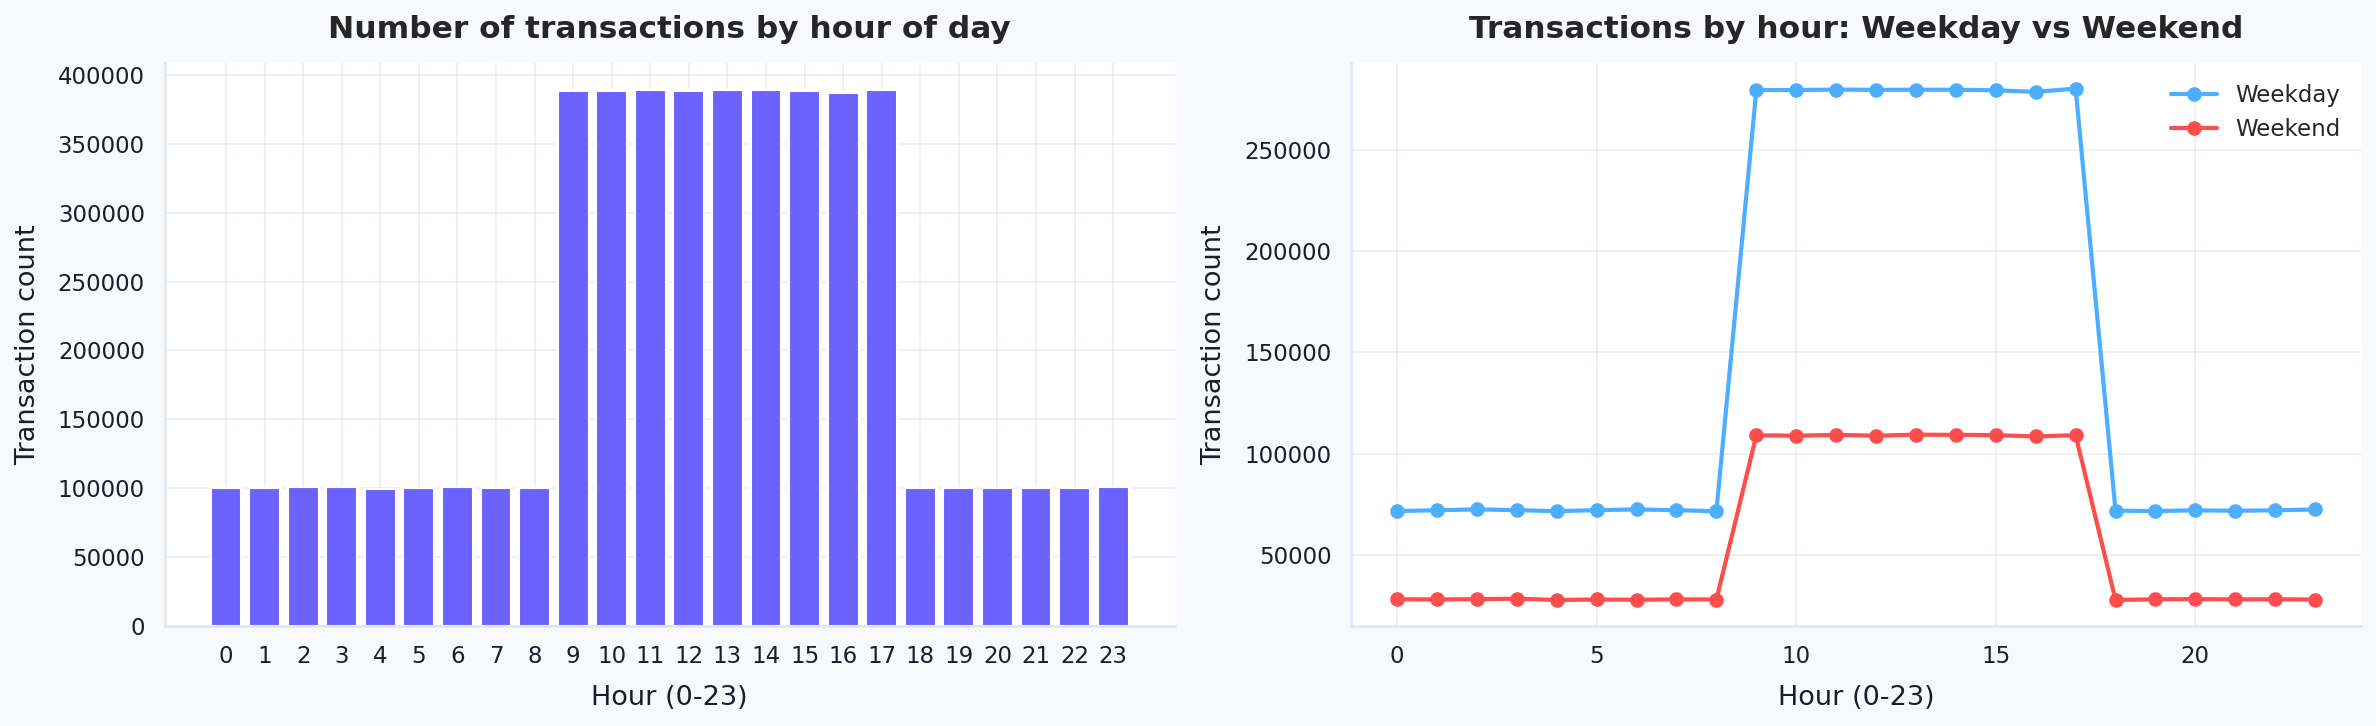

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (a) Number of transactions per hour of day
hour_counts = df["txn_hour"].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values, color=PALETTE_NEUTRAL, edgecolor="white")
# annotate_bars(axes[0], fmt="{:,.0f}")
axes[0].set_title("Number of transactions by hour of day")
axes[0].set_xlabel("Hour (0-23)")
axes[0].set_ylabel("Transaction count")
axes[0].set_xticks(range(0, 24))

# (b) Hourly pattern: weekday vs weekend
weekend_map = df.groupby(["txn_hour", "is_weekend"]).size().unstack(fill_value=0)
weekend_map.columns = ["Weekday", "Weekend"]
weekend_map.plot(kind="line", marker="o", ax=axes[1],
                  color=[PALETTE_LEGIT, PALETTE_FRAUD], linewidth=2)
axes[1].set_title("Transactions by hour: Weekday vs Weekend")
axes[1].set_xlabel("Hour (0-23)")
axes[1].set_ylabel("Transaction count")
axes[1].legend(title=None, frameon=False)

plt.tight_layout()
plt.show()

## 2. Which sender persona has the most fraud?
Left: raw fraud count per `sender_persona`. Right: fraud rate (%) per persona - fairer comparison since each persona has different transaction volume.

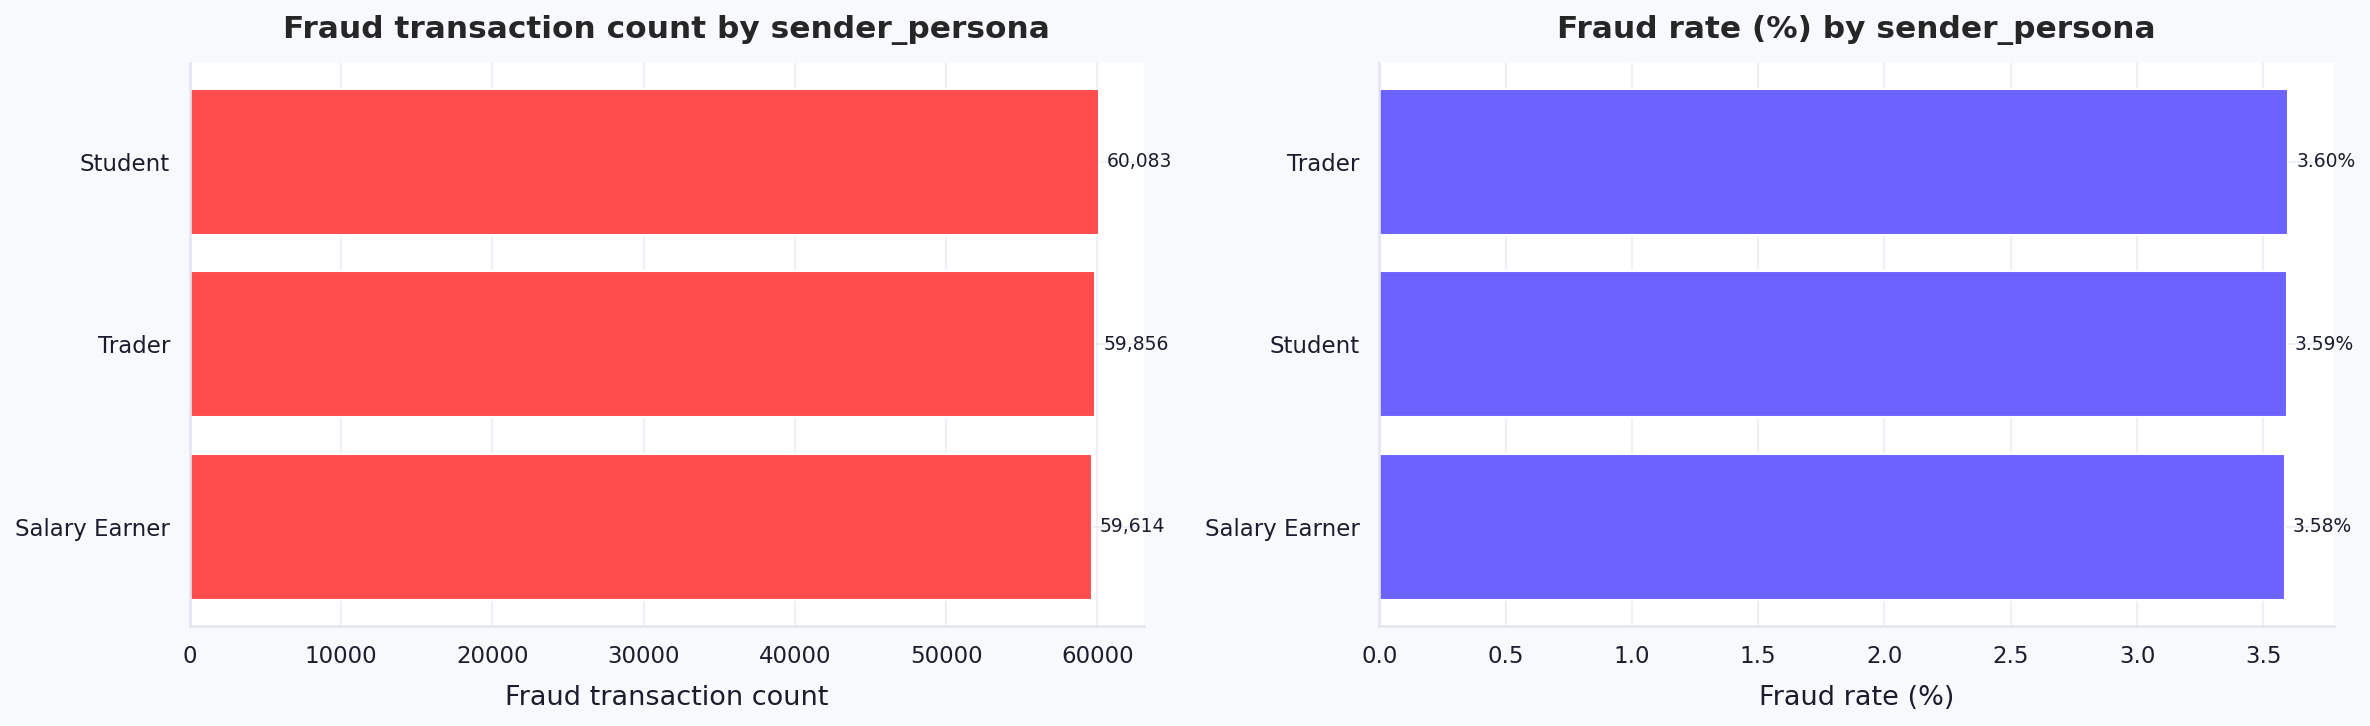

Fraud count by persona:
sender_persona
Student          60083
Trader           59856
Salary Earner    59614

Fraud rate (%) by persona:
sender_persona
Trader           3.598
Student          3.592
Salary Earner    3.584


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

persona_fraud_count = (
    df[df["is_fraud"] == 1]["sender_persona"]
    .value_counts()
    .sort_values(ascending=False)
)
axes[0].barh(persona_fraud_count.index[::-1], persona_fraud_count.values[::-1],
             color=PALETTE_FRAUD, edgecolor="white")
annotate_bars(axes[0], fmt="{:,.0f}")
axes[0].set_title("Fraud transaction count by sender_persona")
axes[0].set_xlabel("Fraud transaction count")

persona_rate = df.groupby("sender_persona")["is_fraud"].mean().sort_values(ascending=False) * 100
axes[1].barh(persona_rate.index[::-1], persona_rate.values[::-1],
             color=PALETTE_NEUTRAL, edgecolor="white")
annotate_bars(axes[1], fmt="{:.2f}%")
axes[1].set_title("Fraud rate (%) by sender_persona")
axes[1].set_xlabel("Fraud rate (%)")

plt.tight_layout()
plt.show()

print("Fraud count by persona:")
print(persona_fraud_count.to_string())
print("\nFraud rate (%) by persona:")
print(persona_rate.round(3).to_string())


## 3. Top IP addresses with the most fraud
Top N (default `TOP_N`) `ip_address` values ranked by number of fraudulent transactions.

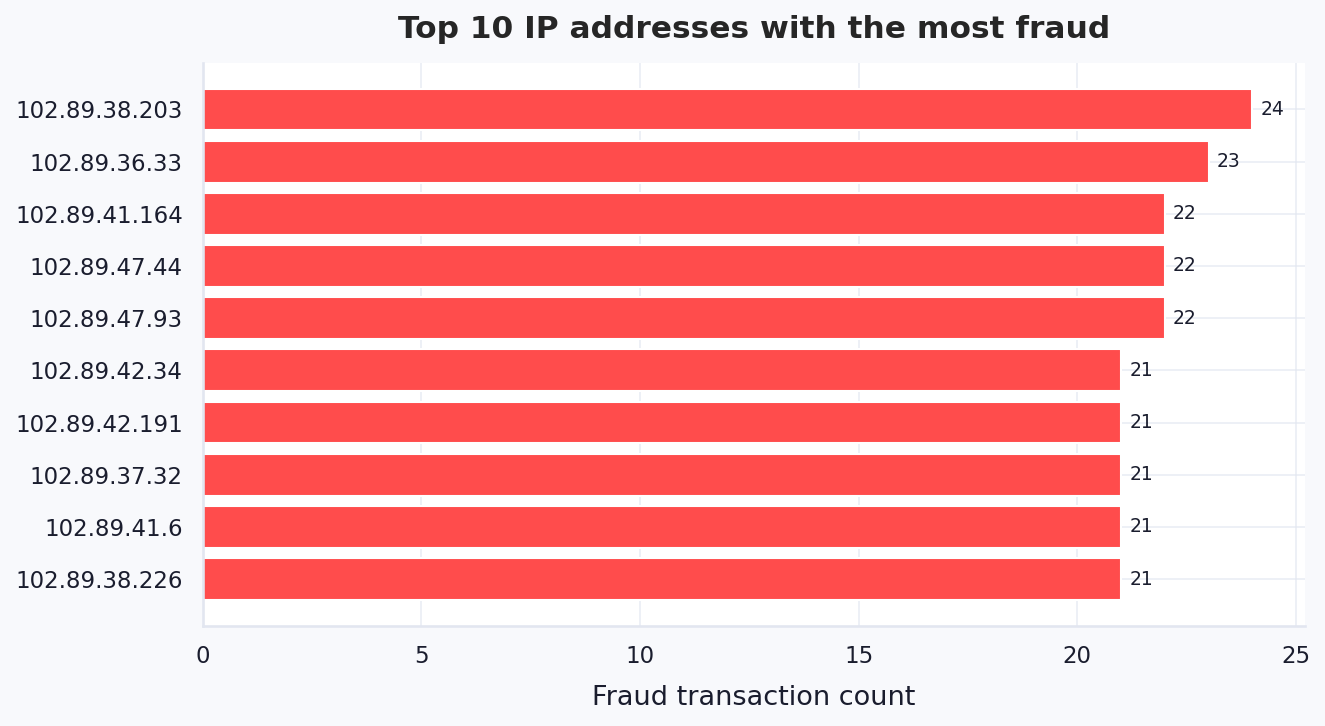

ip_address
102.89.38.203    24
102.89.36.33     23
102.89.47.44     22
102.89.41.164    22
102.89.47.93     22
102.89.38.226    21
102.89.41.6      21
102.89.42.34     21
102.89.37.32     21
102.89.42.191    21


In [ ]:
ip_fraud_count = (
    df[df["is_fraud"] == 1]["ip_address"]
    .value_counts()
    .head(TOP_N)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(9, max(5, TOP_N * 0.4)))
ax.barh(ip_fraud_count.index.astype(str), ip_fraud_count.values,
        color=PALETTE_FRAUD, edgecolor="white")
annotate_bars(ax, fmt="{:,.0f}")
ax.set_title(f"Top {TOP_N} IP addresses with the most fraud")
ax.set_xlabel("Fraud transaction count")
plt.tight_layout()
plt.show()

print(ip_fraud_count.sort_values(ascending=False).to_string())


## 4a. Fraud vs Non-Fraud by Transaction Type
Compares fraud vs non-fraud transactions across each `transaction_type` (absolute count and fraud rate %).

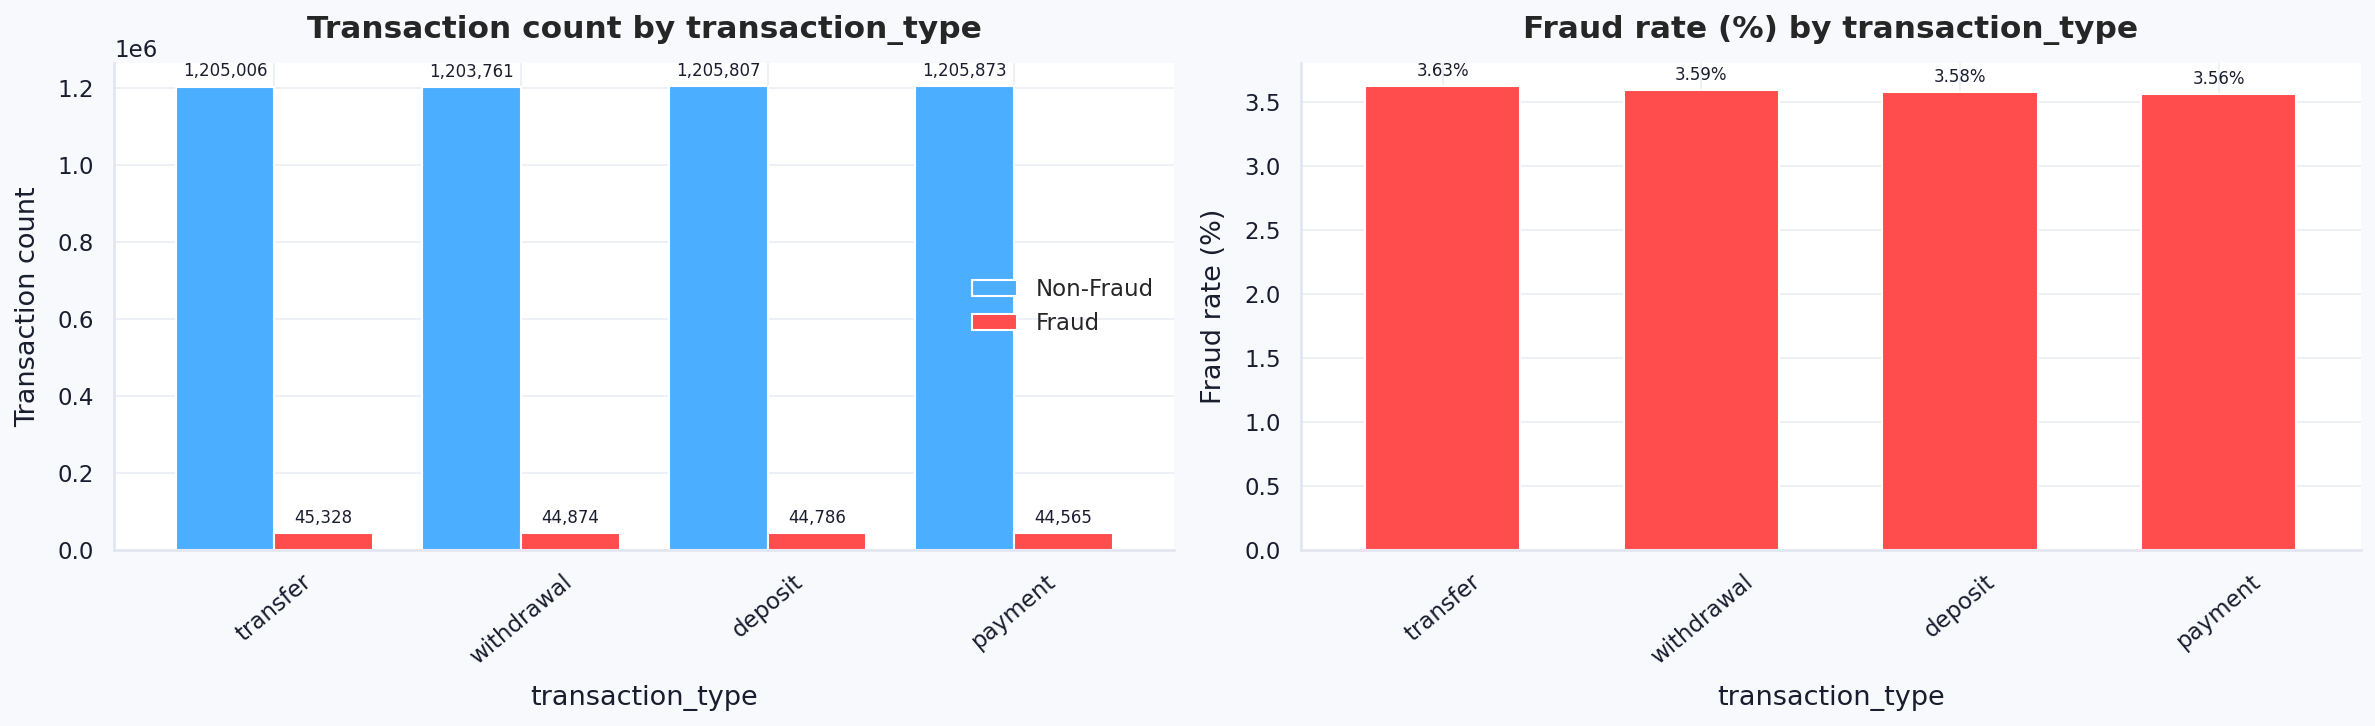

Count table:
                  Non-Fraud  Fraud
transaction_type                  
transfer            1205006  45328
withdrawal          1203761  44874
deposit             1205807  44786
payment             1205873  44565

Fraud rate (%) table:
                  Non-Fraud  Fraud
transaction_type                  
transfer             96.375  3.625
withdrawal           96.406  3.594
deposit              96.419  3.581
payment              96.436  3.564


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (a) Absolute count: Fraud vs Non-Fraud per category
ct_count = pd.crosstab(df["transaction_type"], df["is_fraud"])
ct_count.columns = [FRAUD_LABELS[c] for c in ct_count.columns]
ct_count = ct_count.sort_values("Fraud", ascending=False)
ct_count.plot(kind="bar", ax=axes[0],
              color=[PALETTE_LEGIT, PALETTE_FRAUD], edgecolor="white", width=0.8)
axes[0].set_title(f"Transaction count by transaction_type")
axes[0].set_xlabel("transaction_type")
axes[0].set_ylabel("Transaction count")
axes[0].tick_params(axis="x", rotation=40)
axes[0].legend(frameon=False)
annotate_bars(axes[0], fmt="{:,.0f}", fontsize=8)

# (b) Fraud rate (%) normalized within each category
ct_pct = pd.crosstab(df["transaction_type"], df["is_fraud"], normalize="index") * 100
ct_pct.columns = [FRAUD_LABELS[c] for c in ct_pct.columns]
ct_pct = ct_pct.sort_values("Fraud", ascending=False)
ct_pct[["Fraud"]].plot(kind="bar", ax=axes[1], color=PALETTE_FRAUD,
                        edgecolor="white", width=0.6, legend=False)
axes[1].set_title(f"Fraud rate (%) by transaction_type")
axes[1].set_xlabel("transaction_type")
axes[1].set_ylabel("Fraud rate (%)")
axes[1].tick_params(axis="x", rotation=40)
annotate_bars(axes[1], fmt="{:.2f}%", fontsize=8)

plt.tight_layout()
plt.show()

print("Count table:")
print(ct_count.to_string())
print("\nFraud rate (%) table:")
print(ct_pct.round(3).to_string())


## 4b. Fraud vs Non-Fraud by Payment Channel
Compares fraud vs non-fraud transactions across each `payment_channel`.

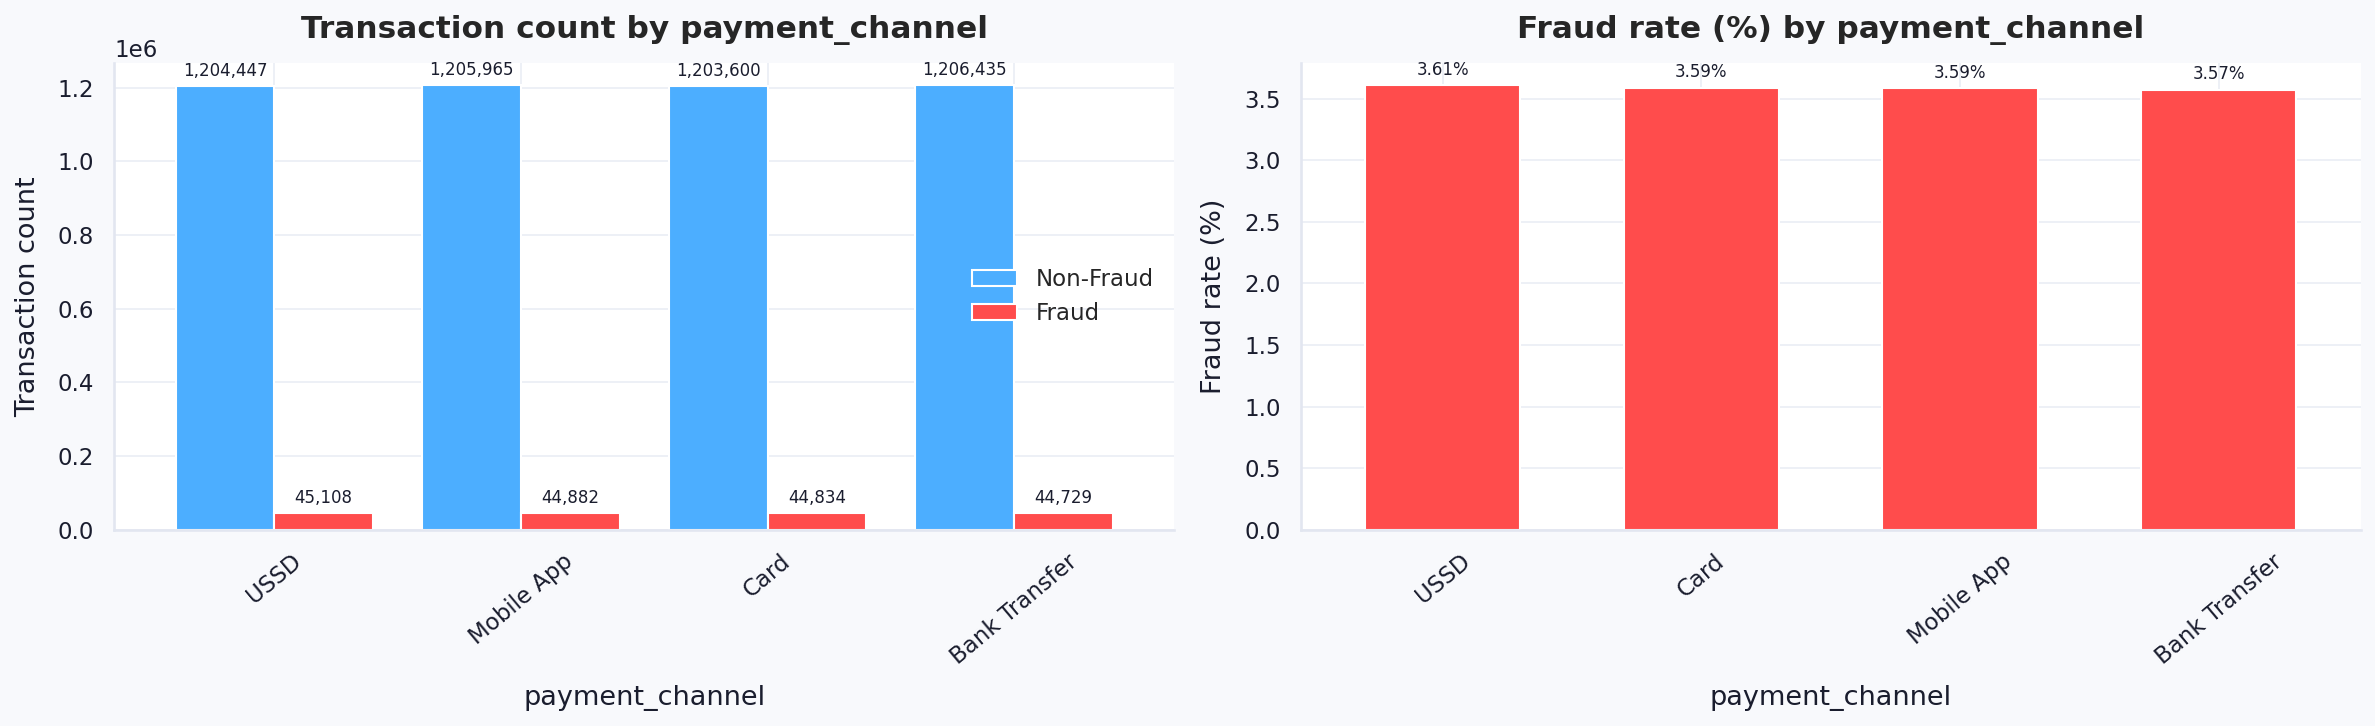

Count table:
                 Non-Fraud  Fraud
payment_channel                  
USSD               1204447  45108
Mobile App         1205965  44882
Card               1203600  44834
Bank Transfer      1206435  44729

Fraud rate (%) table:
                 Non-Fraud  Fraud
payment_channel                  
USSD                96.390  3.610
Card                96.409  3.591
Mobile App          96.412  3.588
Bank Transfer       96.425  3.575


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (a) Absolute count: Fraud vs Non-Fraud per category
ct_count = pd.crosstab(df["payment_channel"], df["is_fraud"])
ct_count.columns = [FRAUD_LABELS[c] for c in ct_count.columns]
ct_count = ct_count.sort_values("Fraud", ascending=False)
ct_count.plot(kind="bar", ax=axes[0],
              color=[PALETTE_LEGIT, PALETTE_FRAUD], edgecolor="white", width=0.8)
axes[0].set_title(f"Transaction count by payment_channel")
axes[0].set_xlabel("payment_channel")
axes[0].set_ylabel("Transaction count")
axes[0].tick_params(axis="x", rotation=40)
axes[0].legend(frameon=False)
annotate_bars(axes[0], fmt="{:,.0f}", fontsize=8)

# (b) Fraud rate (%) normalized within each category
ct_pct = pd.crosstab(df["payment_channel"], df["is_fraud"], normalize="index") * 100
ct_pct.columns = [FRAUD_LABELS[c] for c in ct_pct.columns]
ct_pct = ct_pct.sort_values("Fraud", ascending=False)
ct_pct[["Fraud"]].plot(kind="bar", ax=axes[1], color=PALETTE_FRAUD,
                        edgecolor="white", width=0.6, legend=False)
axes[1].set_title(f"Fraud rate (%) by payment_channel")
axes[1].set_xlabel("payment_channel")
axes[1].set_ylabel("Fraud rate (%)")
axes[1].tick_params(axis="x", rotation=40)
annotate_bars(axes[1], fmt="{:.2f}%", fontsize=8)

plt.tight_layout()
plt.show()

print("Count table:")
print(ct_count.to_string())
print("\nFraud rate (%) table:")
print(ct_pct.round(3).to_string())


## 4c. Fraud vs Non-Fraud by Device Used
Compares fraud vs non-fraud transactions across each `device_used`.

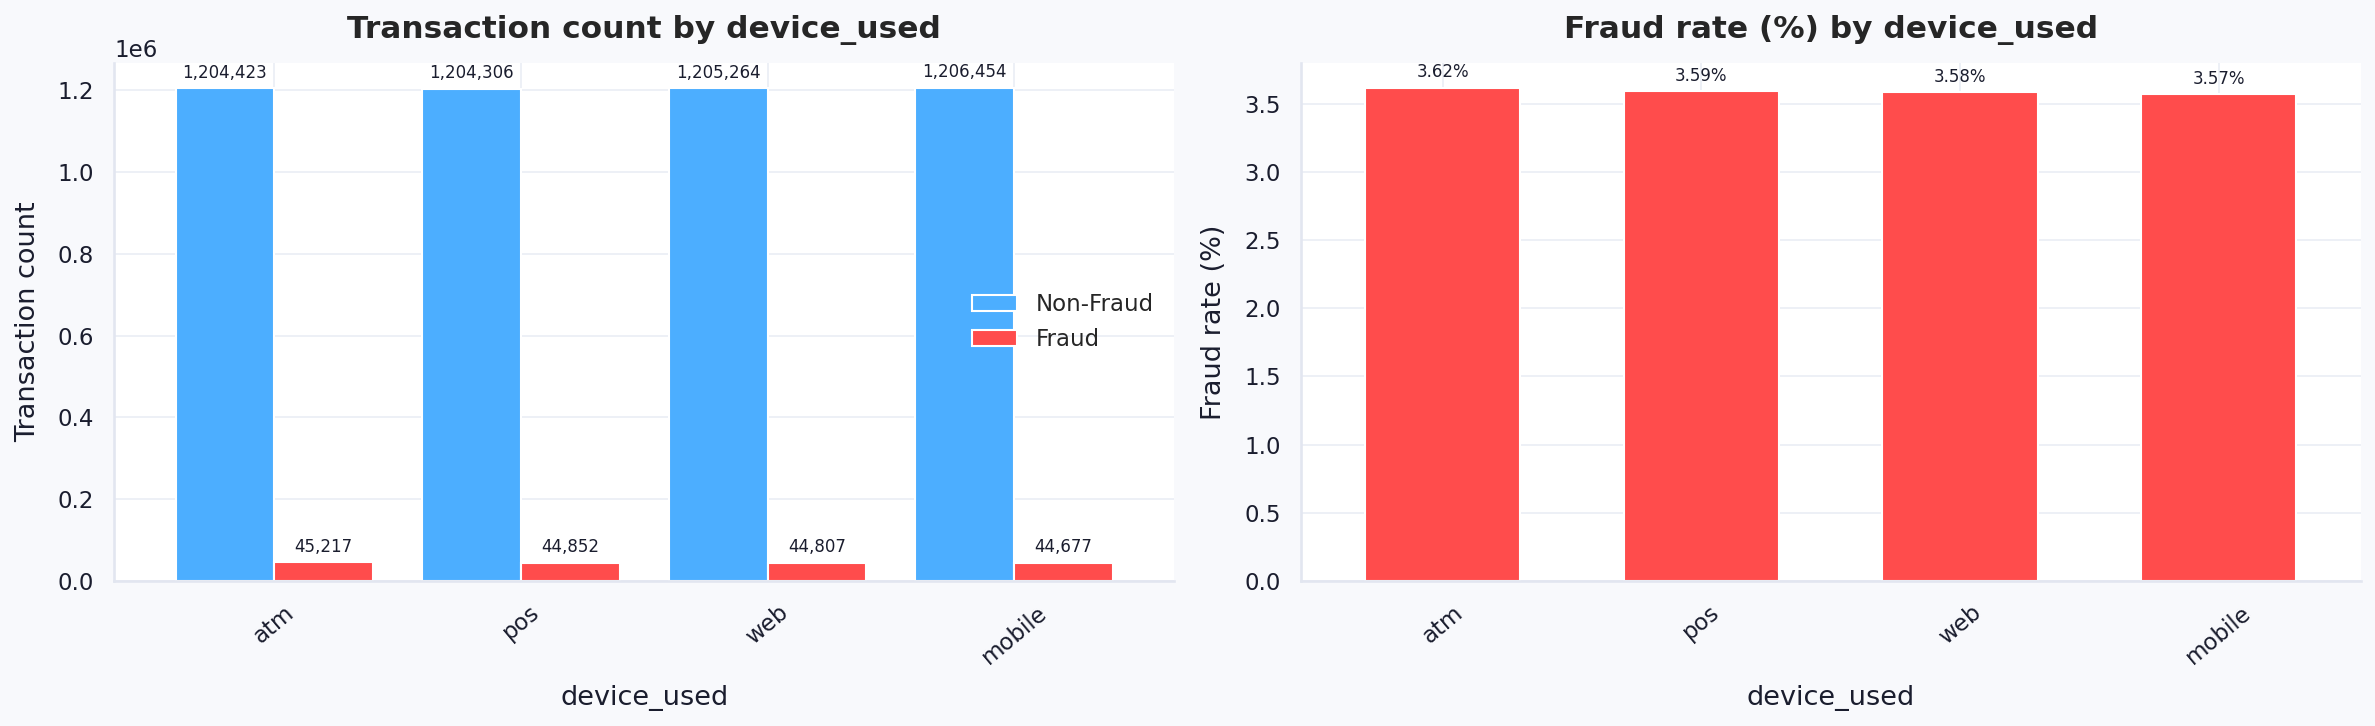

Count table:
             Non-Fraud  Fraud
device_used                  
atm            1204423  45217
pos            1204306  44852
web            1205264  44807
mobile         1206454  44677

Fraud rate (%) table:
             Non-Fraud  Fraud
device_used                  
atm             96.382  3.618
pos             96.409  3.591
web             96.416  3.584
mobile          96.429  3.571


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (a) Absolute count: Fraud vs Non-Fraud per category
ct_count = pd.crosstab(df["device_used"], df["is_fraud"])
ct_count.columns = [FRAUD_LABELS[c] for c in ct_count.columns]
ct_count = ct_count.sort_values("Fraud", ascending=False)
ct_count.plot(kind="bar", ax=axes[0],
              color=[PALETTE_LEGIT, PALETTE_FRAUD], edgecolor="white", width=0.8)
axes[0].set_title(f"Transaction count by device_used")
axes[0].set_xlabel("device_used")
axes[0].set_ylabel("Transaction count")
axes[0].tick_params(axis="x", rotation=40)
axes[0].legend(frameon=False)
annotate_bars(axes[0], fmt="{:,.0f}", fontsize=8)

# (b) Fraud rate (%) normalized within each category
ct_pct = pd.crosstab(df["device_used"], df["is_fraud"], normalize="index") * 100
ct_pct.columns = [FRAUD_LABELS[c] for c in ct_pct.columns]
ct_pct = ct_pct.sort_values("Fraud", ascending=False)
ct_pct[["Fraud"]].plot(kind="bar", ax=axes[1], color=PALETTE_FRAUD,
                        edgecolor="white", width=0.6, legend=False)
axes[1].set_title(f"Fraud rate (%) by device_used")
axes[1].set_xlabel("device_used")
axes[1].set_ylabel("Fraud rate (%)")
axes[1].tick_params(axis="x", rotation=40)
annotate_bars(axes[1], fmt="{:.2f}%", fontsize=8)

plt.tight_layout()
plt.show()

print("Count table:")
print(ct_count.to_string())
print("\nFraud rate (%) table:")
print(ct_pct.round(3).to_string())


## 5. Top merchant categories by transaction volume
Top N `merchant_category` values ranked by total number of transactions (fraud + non-fraud).

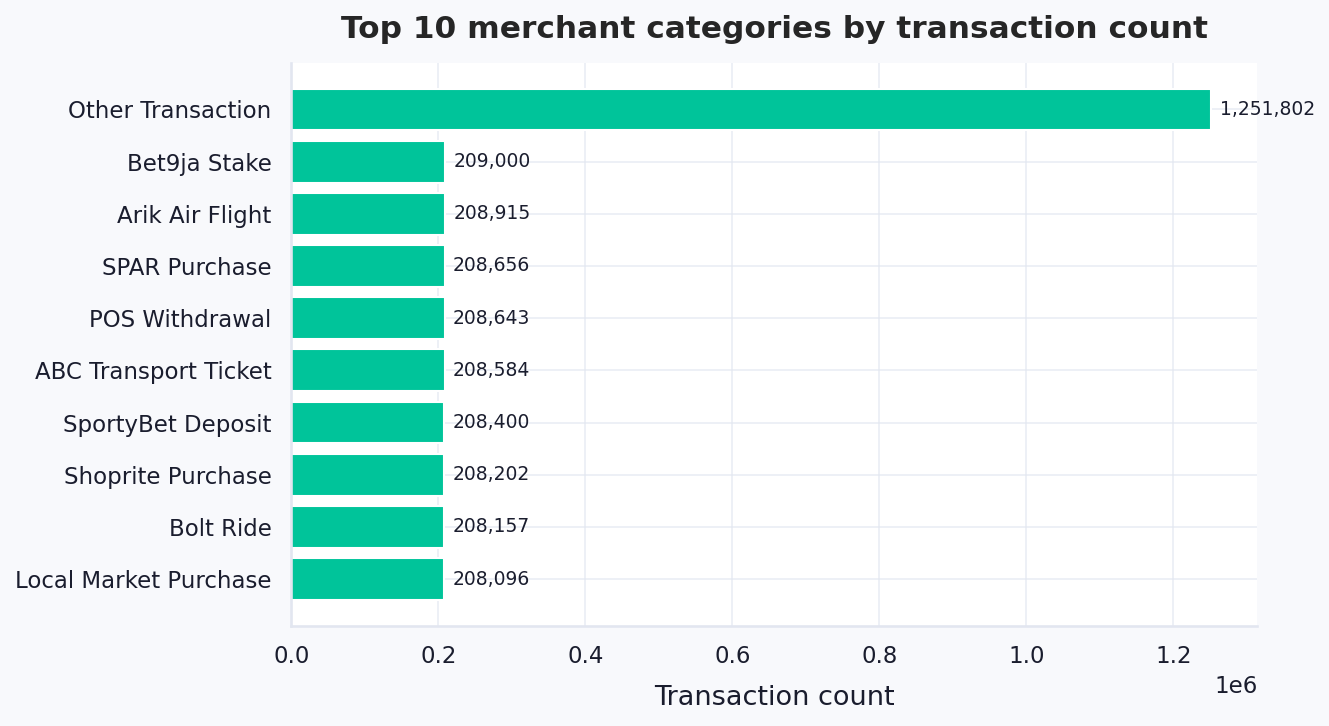

merchant_category
Other Transaction        1251802
Bet9ja Stake              209000
Arik Air Flight           208915
SPAR Purchase             208656
POS Withdrawal            208643
ABC Transport Ticket      208584
SportyBet Deposit         208400
Shoprite Purchase         208202
Bolt Ride                 208157
Local Market Purchase     208096


In [ ]:
merchant_counts = df["merchant_category"].value_counts().head(TOP_N).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, max(5, TOP_N * 0.4)))
ax.barh(merchant_counts.index.astype(str), merchant_counts.values,
        color=PALETTE_MERCHANT, edgecolor="white")
annotate_bars(ax, fmt="{:,.0f}")
ax.set_title(f"Top {TOP_N} merchant categories by transaction count")
ax.set_xlabel("Transaction count")
plt.tight_layout()
plt.show()

print(merchant_counts.sort_values(ascending=False).to_string())


## 6. Are transaction amounts usually low or high?
Distribution of `amount_ngn` on both linear and log scale, plus mean/median markers to detect right-skew.

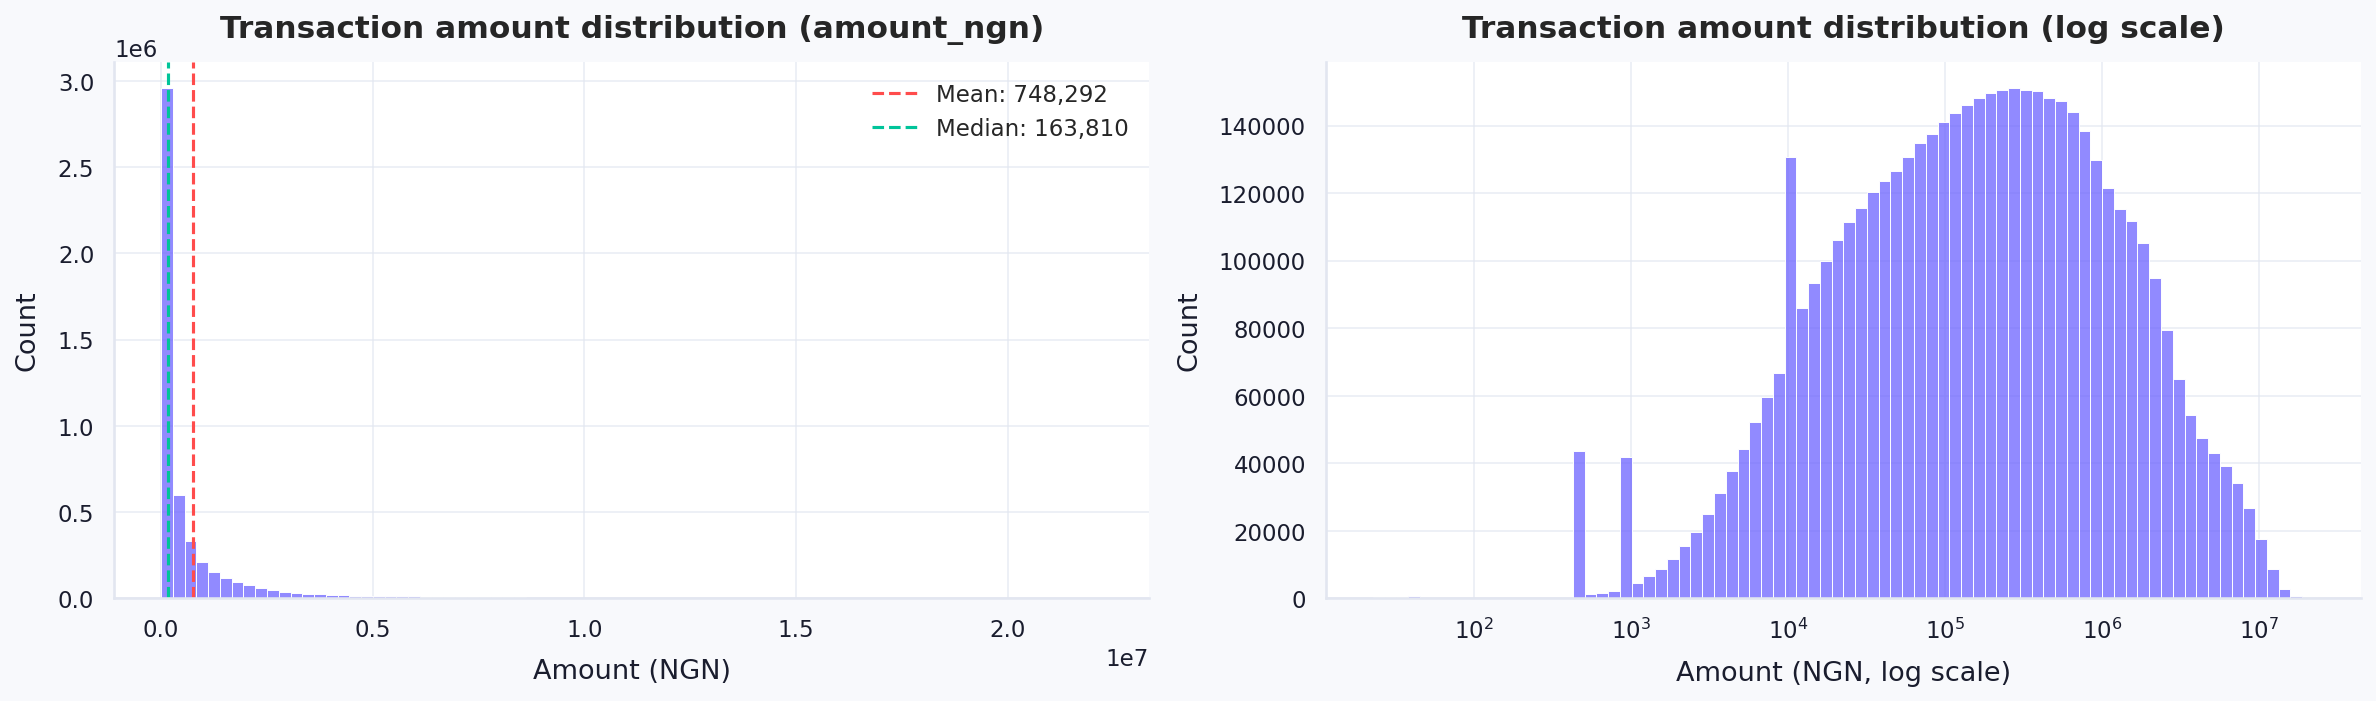

Count:  5,000,000
Mean:   748,292.44 NGN
Median: 163,810.03 NGN
Min:    22.81 NGN
Max:    22,230,670.00 NGN
-> If Mean >> Median: right-skewed distribution (most transactions are small, a few are very large).


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(df["amount_ngn"], bins=80, color=PALETTE_NEUTRAL, ax=axes[0], kde=False)
mean_val = df["amount_ngn"].mean()
median_val = df["amount_ngn"].median()
axes[0].axvline(mean_val, color=PALETTE_FRAUD, linestyle="--", linewidth=1.5,
                 label=f"Mean: {mean_val:,.0f}")
axes[0].axvline(median_val, color=PALETTE_MERCHANT, linestyle="--", linewidth=1.5,
                 label=f"Median: {median_val:,.0f}")
axes[0].set_title("Transaction amount distribution (amount_ngn)")
axes[0].set_xlabel("Amount (NGN)")
axes[0].legend(frameon=False)

sns.histplot(df["amount_ngn"], bins=80, color=PALETTE_NEUTRAL, ax=axes[1], kde=False, log_scale=True)
axes[1].set_title("Transaction amount distribution (log scale)")
axes[1].set_xlabel("Amount (NGN, log scale)")

plt.tight_layout()
plt.show()

print(f"Count:  {df['amount_ngn'].count():,}")
print(f"Mean:   {mean_val:,.2f} NGN")
print(f"Median: {median_val:,.2f} NGN")
print(f"Min:    {df['amount_ngn'].min():,.2f} NGN")
print(f"Max:    {df['amount_ngn'].max():,.2f} NGN")
print("-> If Mean >> Median: right-skewed distribution (most transactions are small, a few are very large).")


## 7. Fraud vs Non-Fraud ratio
Overall proportion of `is_fraud` (0 = non-fraud, 1 = fraud) in the whole dataset - typically a highly imbalanced ratio.

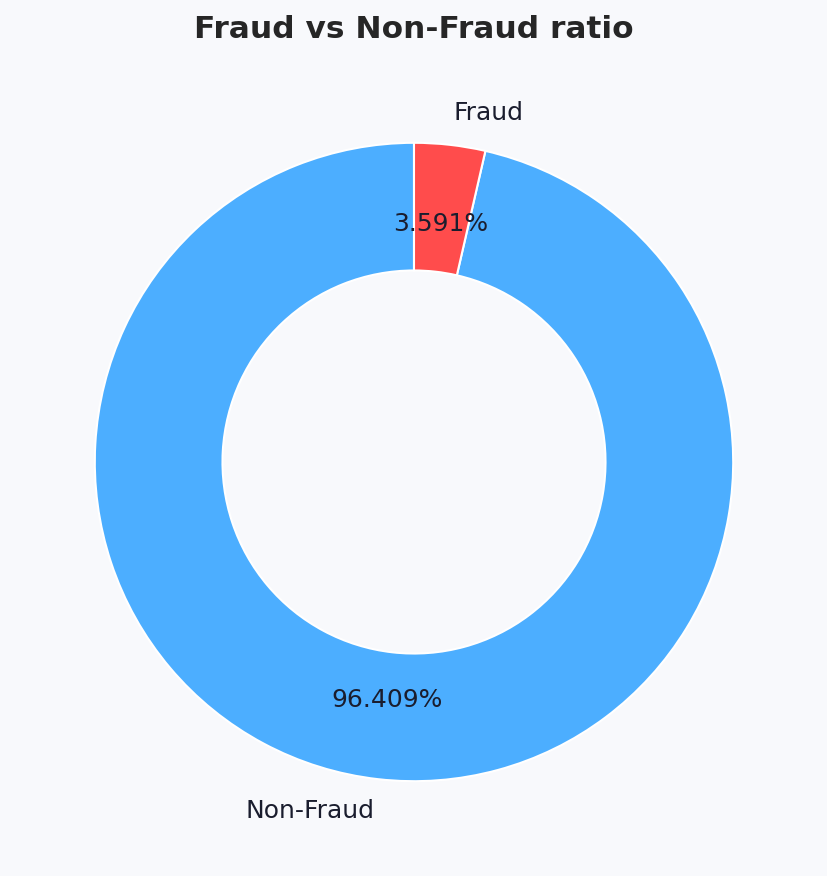

Non-Fraud: 4,820,447 transactions (96.4089%)
Fraud: 179,553 transactions (3.5911%)


In [ ]:
counts = df["is_fraud"].value_counts().sort_index()
labels = [FRAUD_LABELS[i] for i in counts.index]
colors = [FRAUD_COLORS[i] for i in counts.index]

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    counts.values, labels=labels, colors=colors, autopct="%1.3f%%",
    startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.4, edgecolor="white"),
    textprops=dict(color=PALETTE_TEXT, fontsize=12),
)
ax.set_title("Fraud vs Non-Fraud ratio")
plt.tight_layout()
plt.show()

total = counts.sum()
for i, c in counts.items():
    print(f"{FRAUD_LABELS[i]}: {c:,} transactions ({c/total*100:.4f}%)")


## 8. Which location has the most fraud?
Left: top N `location` values ranked by raw fraud count. Right: top N locations ranked by fraud rate (%).

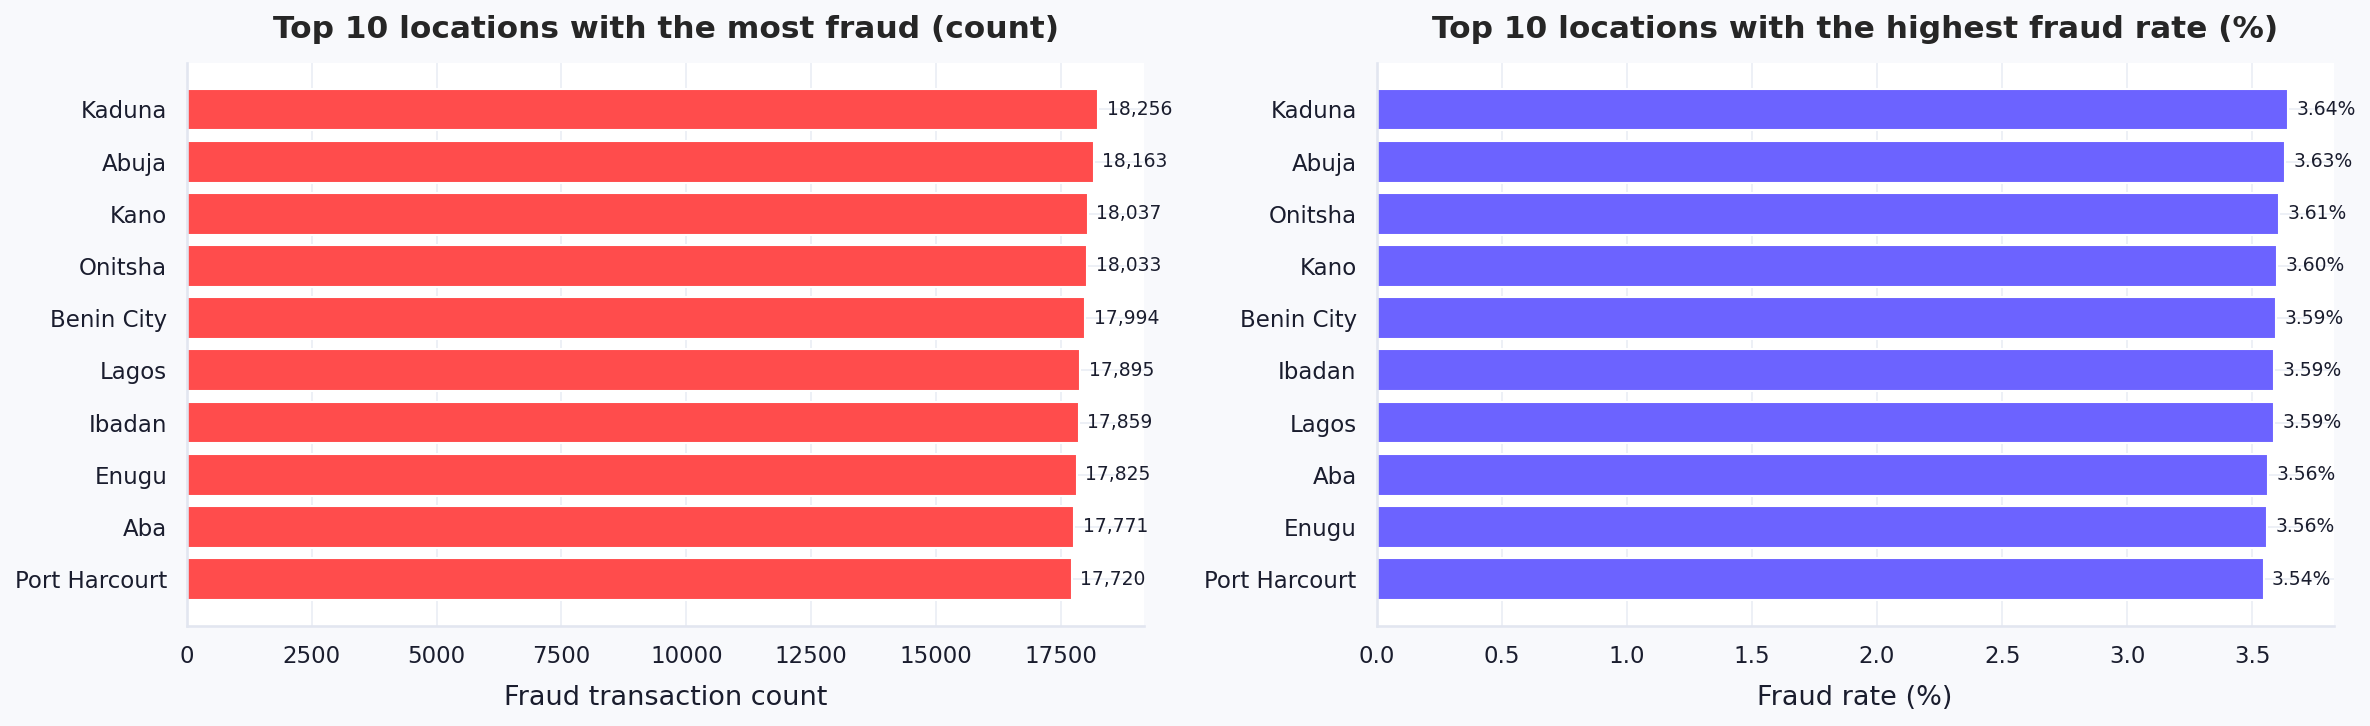

Fraud count by location:
location
Kaduna           18256
Abuja            18163
Kano             18037
Onitsha          18033
Benin City       17994
Lagos            17895
Ibadan           17859
Enugu            17825
Aba              17771
Port Harcourt    17720

Fraud rate (%) by location:
location
Kaduna           3.642
Abuja            3.630
Onitsha          3.607
Kano             3.600
Benin City       3.594
Ibadan           3.587
Lagos            3.585
Aba              3.564
Enugu            3.558
Port Harcourt    3.544


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

loc_fraud_count = (
    df[df["is_fraud"] == 1]["location"]
    .value_counts()
    .head(TOP_N)
    .sort_values(ascending=True)
)
axes[0].barh(loc_fraud_count.index.astype(str), loc_fraud_count.values,
             color=PALETTE_FRAUD, edgecolor="white")
annotate_bars(axes[0], fmt="{:,.0f}")
axes[0].set_title(f"Top {TOP_N} locations with the most fraud (count)")
axes[0].set_xlabel("Fraud transaction count")

loc_fraud_rate = (
    df.groupby("location")["is_fraud"].mean().sort_values(ascending=False).head(TOP_N) * 100
).sort_values(ascending=True)
axes[1].barh(loc_fraud_rate.index.astype(str), loc_fraud_rate.values,
             color=PALETTE_NEUTRAL, edgecolor="white")
annotate_bars(axes[1], fmt="{:.2f}%")
axes[1].set_title(f"Top {TOP_N} locations with the highest fraud rate (%)")
axes[1].set_xlabel("Fraud rate (%)")

plt.tight_layout()
plt.show()

print("Fraud count by location:")
print(loc_fraud_count.sort_values(ascending=False).to_string())
print("\nFraud rate (%) by location:")
print(loc_fraud_rate.sort_values(ascending=False).round(3).to_string())


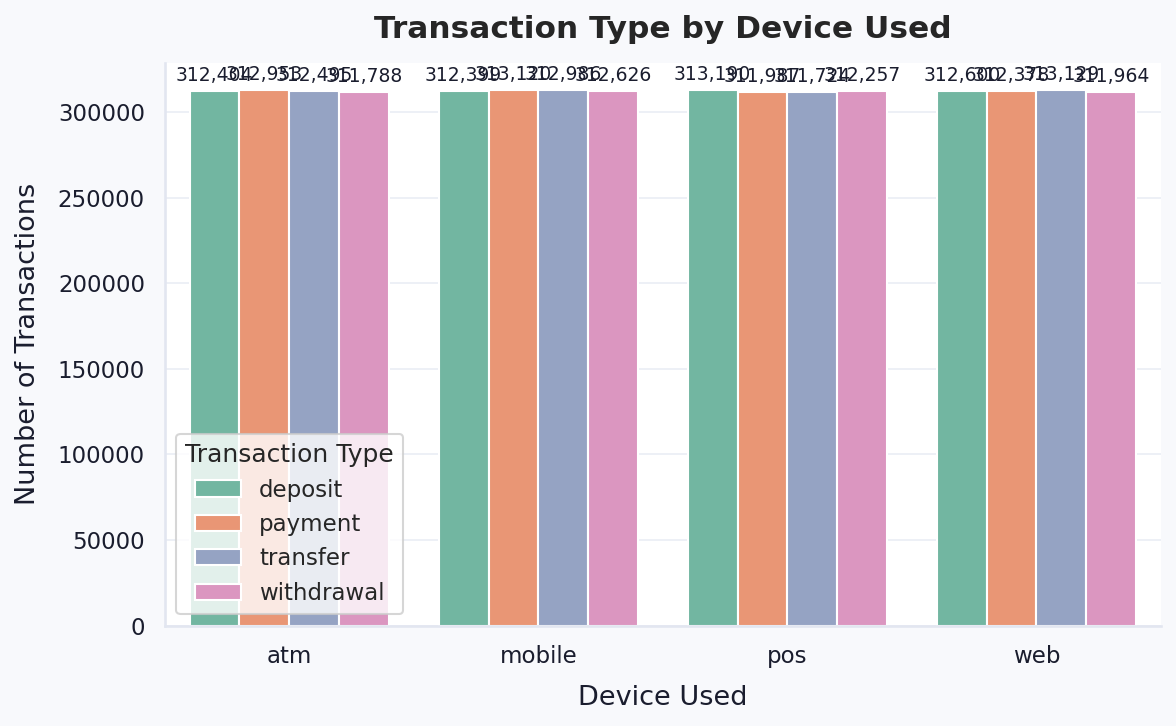

In [8]:
# Chart 1: Device Used vs Transaction Type

fig, ax = plt.subplots(figsize=(8, 5))

sns.countplot(
    data=df,
    x="device_used",
    hue="transaction_type",
    palette="Set2",
    ax=ax
)

annotate_bars(ax)

ax.set_title("Transaction Type by Device Used")
ax.set_xlabel("Device Used")
ax.set_ylabel("Number of Transactions")

ax.legend(
    title="Transaction Type",
    frameon=True,
    facecolor=PALETTE_CARD
)

plt.tight_layout()
plt.show()

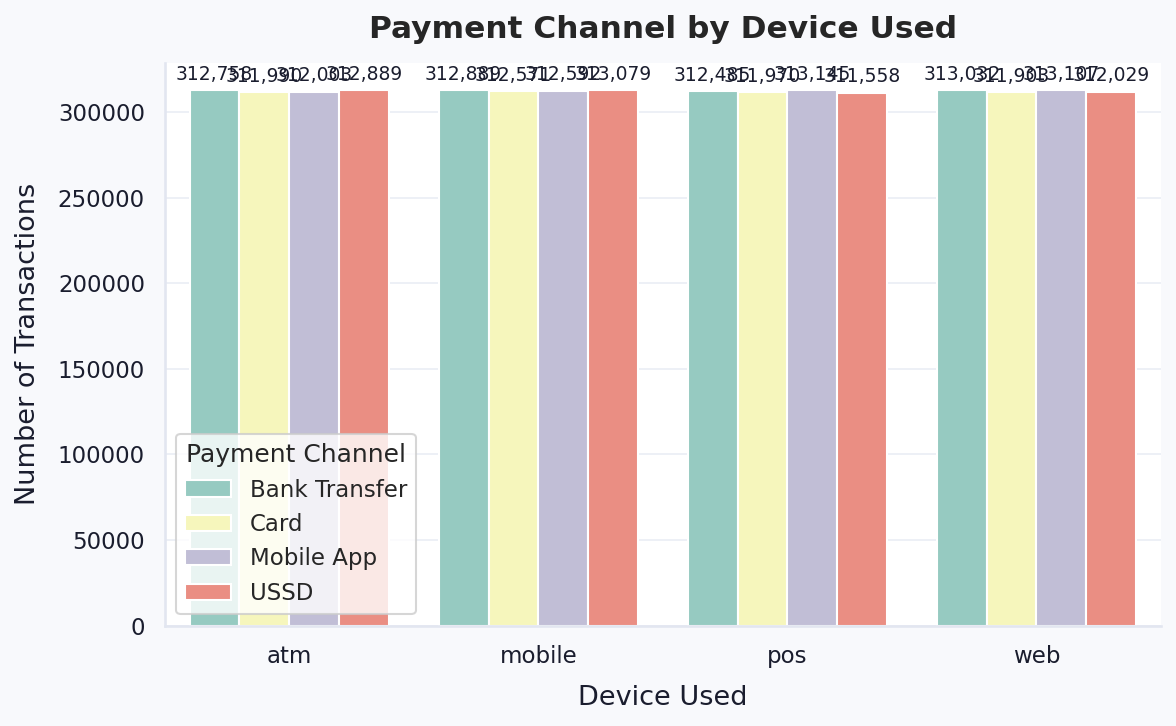

In [9]:
# Chart 2: Device Used vs Payment Channel

fig, ax = plt.subplots(figsize=(8, 5))

sns.countplot(
    data=df,
    x="device_used",
    hue="payment_channel",
    palette="Set3",
    ax=ax
)

annotate_bars(ax)

ax.set_title("Payment Channel by Device Used")
ax.set_xlabel("Device Used")
ax.set_ylabel("Number of Transactions")

ax.legend(
    title="Payment Channel",
    frameon=True,
    facecolor=PALETTE_CARD
)

plt.tight_layout()
plt.show()

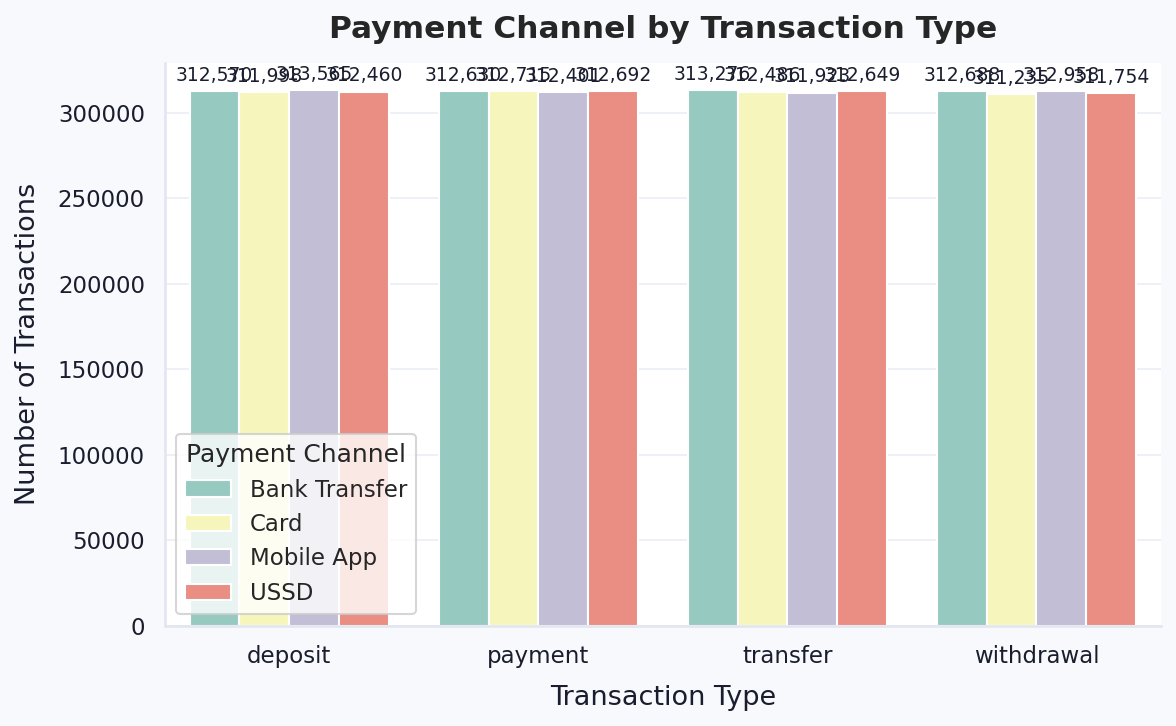

In [10]:
# Chart 3: Transaction Type vs Payment Channel

fig, ax = plt.subplots(figsize=(8, 5))

sns.countplot(
    data=df,
    x="transaction_type",
    hue="payment_channel",
    palette="Set3",
    ax=ax
)

annotate_bars(ax)

ax.set_title("Payment Channel by Transaction Type")
ax.set_xlabel("Transaction Type")
ax.set_ylabel("Number of Transactions")

ax.legend(
    title="Payment Channel",
    frameon=True,
    facecolor=PALETTE_CARD
)

plt.tight_layout()
plt.show()

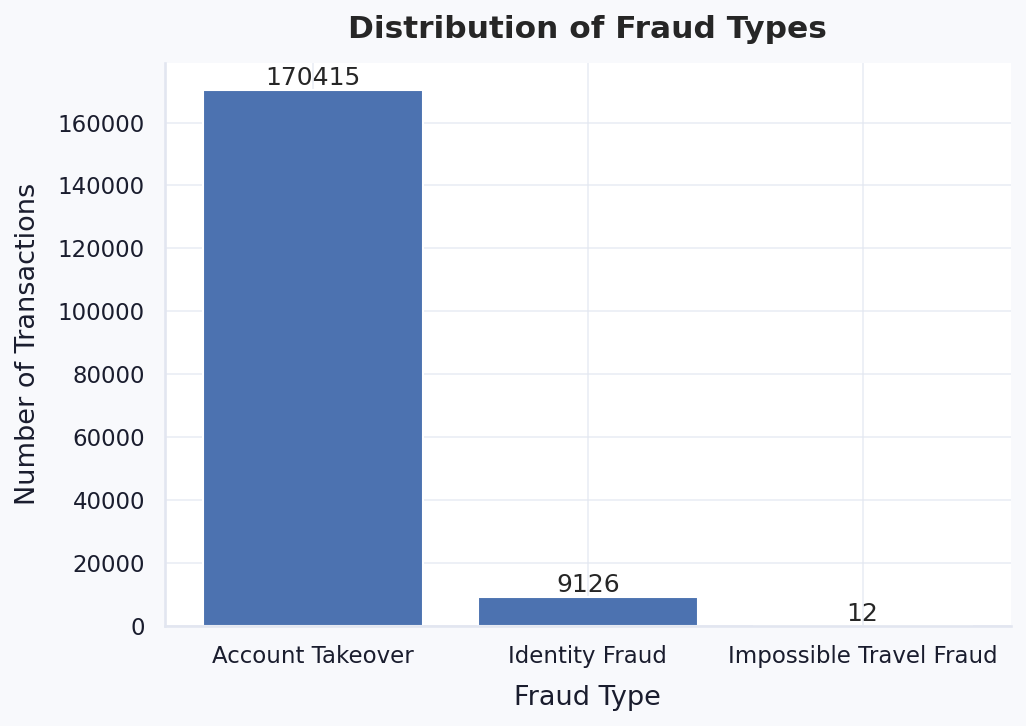

In [13]:
# Count each fraud type
fraud_counts = df["fraud_type"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(fraud_counts.index, fraud_counts.values)

plt.title("Distribution of Fraud Types")
plt.xlabel("Fraud Type")
plt.ylabel("Number of Transactions")

# Show count on top of each bar
for i, count in enumerate(fraud_counts.values):
    plt.text(i, count, str(count), ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [7]:
cols = ['is_fraud', 'fraud_type','transaction_id', 'timestamp', 'sender_account', 'receiver_account',
       'amount_ngn', 'sender_persona', 'location', 'ip_geo_region',
       'ip_address', 'ip_seen_count', 'device_hash', 'transaction_type',
       'device_used', 'payment_channel', 'device_seen_count',
       'merchant_category', 'user_top_category', 'merchant_fraud_rate',
       'channel_risk_score', 'persona_fraud_risk', 'location_fraud_risk',
       'is_weekend', 'is_salary_week', 'is_night_txn', 'is_device_shared',
       'is_ip_shared', 'bvn_linked', 'new_device_transaction',
       'time_since_last', 'time_since_last_transaction', 'txn_count_last_1h',
       'txn_count_last_24h', 'total_amount_last_1h', 'user_txn_frequency_24h',
       'user_txn_count_total', 'user_avg_txn_amt', 'user_std_txn_amt',
       'avg_gap_between_txns', 'txn_hour', 'spending_deviation_score',
       'velocity_score', 'geo_anomaly_score', 'geospatial_velocity_anomaly'
       ]
df = df[cols]
df

,is_fraud,fraud_type,transaction_id,timestamp,sender_account,receiver_account,amount_ngn,sender_persona,location,ip_geo_region,...,user_txn_frequency_24h,user_txn_count_total,user_avg_txn_amt,user_std_txn_amt,avg_gap_between_txns,txn_hour,spending_deviation_score,velocity_score,geo_anomaly_score,geospatial_velocity_anomaly
0,0,NaN,T2162315,2023-01-24 09:54:06.198396,1000018177,8385560081,654135.062500,Student,Aba,South East,...,1,10,6.541351e+05,0.000000e+00,0.000000,9,-0.36,12,0.98,0
1,0,NaN,T1764581,2023-02-22 16:16:19.271951,1000018177,5643014197,33314.031250,Student,Onitsha,South East,...,2,10,3.437246e+05,4.389868e+05,21071.109375,16,0.07,8,0.71,0
2,0,NaN,T3305551,2023-05-04 16:01:42.312142,1000018177,7722691989,32536.660156,Student,Onitsha,South East,...,3,10,2.399952e+05,3.586558e+05,48122.535156,16,1.95,10,0.56,0
3,0,NaN,T174955,2023-05-07 13:15:03.037215,1000018177,4987435115,13445.110352,Student,Benin City,South South,...,4,10,1.833577e+05,3.139861e+05,37130.238281,13,-1.13,19,0.35,0
4,0,NaN,T3695059,2023-06-08 11:37:39.155188,1000018177,7939643449,125112.562500,Student,Aba,South East,...,5,10,1.717087e+05,2.731647e+05,38900.710938,11,-1.47,9,0.03,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,0,NaN,T2319152,2023-11-23 16:22:20.971217,9999973159,5340639823,583207.312500,Trader,Onitsha,South East,...,8,9,2.226268e+06,3.886392e+06,53822.496094,16,0.04,15,0.25,0
4999996,1,Account Takeover,T2833155,2023-12-25 13:12:33.898607,9999973159,9337859305,644781.125000,Trader,Aba,South East,...,9,9,2.050547e+06,3.673410e+06,52941.132812,13,-0.37,18,0.40,0
4999997,0,NaN,T2602571,2023-04-04 13:10:39.842999,9999981583,2181306123,26377.500000,Student,Kano,North West,...,1,3,2.637750e+04,0.000000e+00,0.000000,13,-1.09,10,0.83,0
4999998,0,NaN,T3602783,2023-06-05 06:58:30.601173,9999981583,2393061148,17437.429688,Student,Enugu,South East,...,2,3,2.190746e+04,6.321584e+03,44453.921875,6,0.70,8,0.56,0


/tmp/ipykernel_32693/3551162610.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


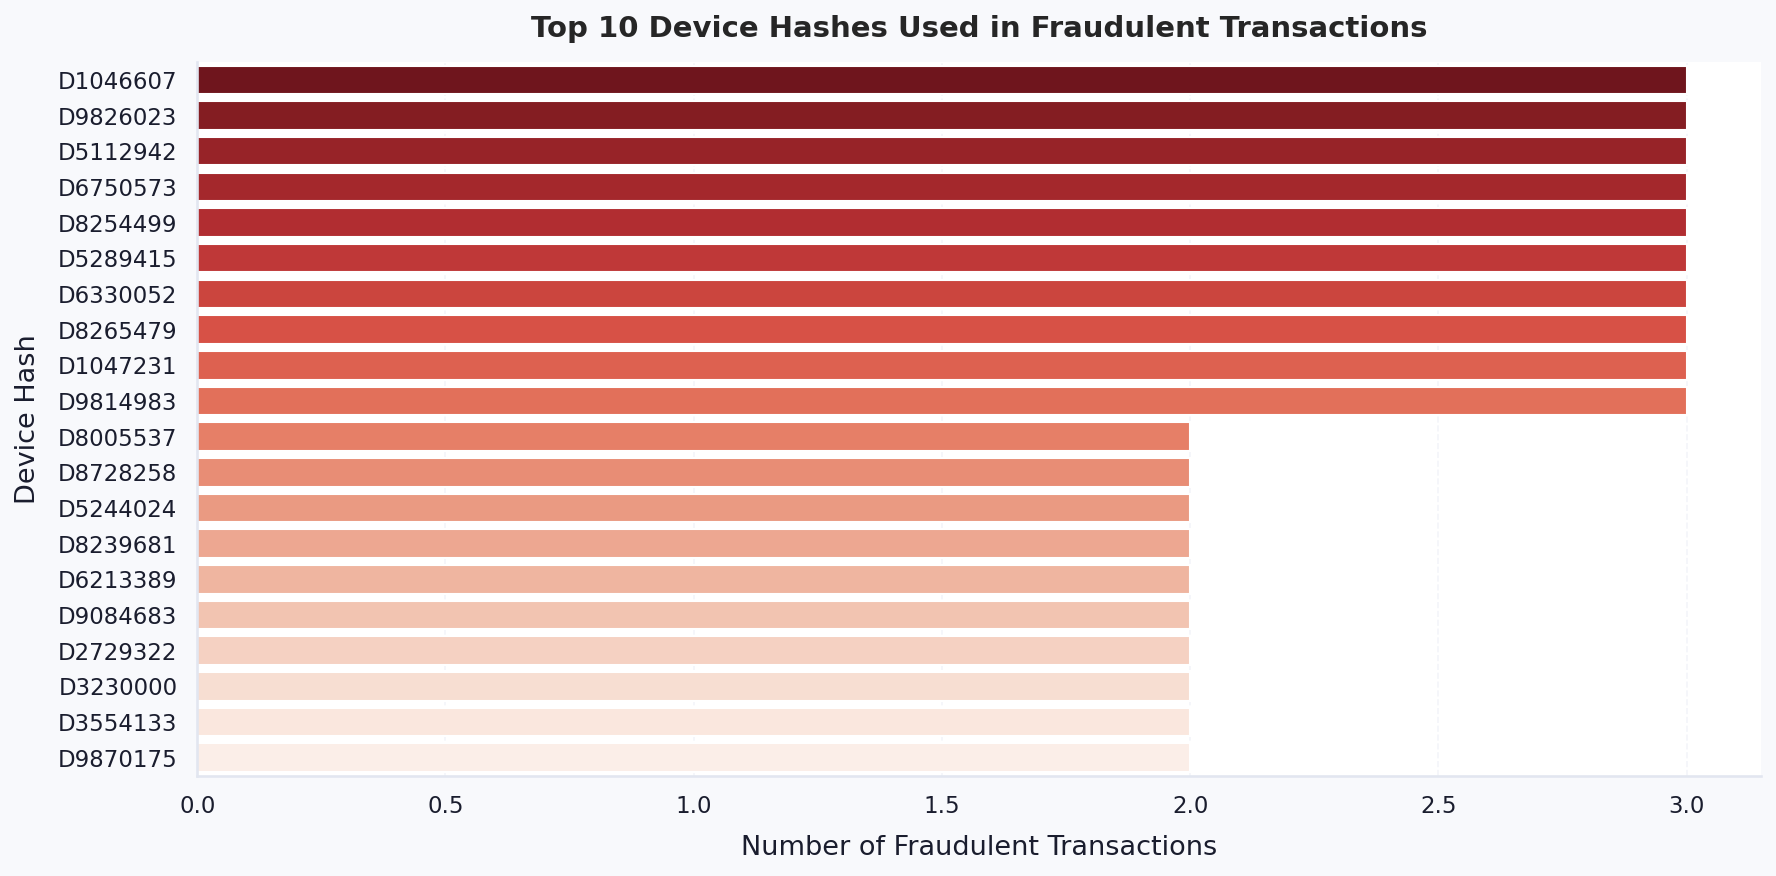

In [20]:
# Filter fraudulent transactions
fraud_devices = df[df["is_fraud"] == 1]

# Count fraudulent transactions by device_hash
top10_devices = (
    fraud_devices["device_hash"]
    .value_counts()
    .head(20)
    .reset_index()
)

top10_devices.columns = ["device_hash", "fraud_count"]

# Plot
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top10_devices,
    x="fraud_count",
    y="device_hash",
    palette="Reds_r"
)

plt.title("Top 10 Device Hashes Used in Fraudulent Transactions", fontsize=14, weight="bold")
plt.xlabel("Number of Fraudulent Transactions")
plt.ylabel("Device Hash")
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

/tmp/ipykernel_32693/187898490.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


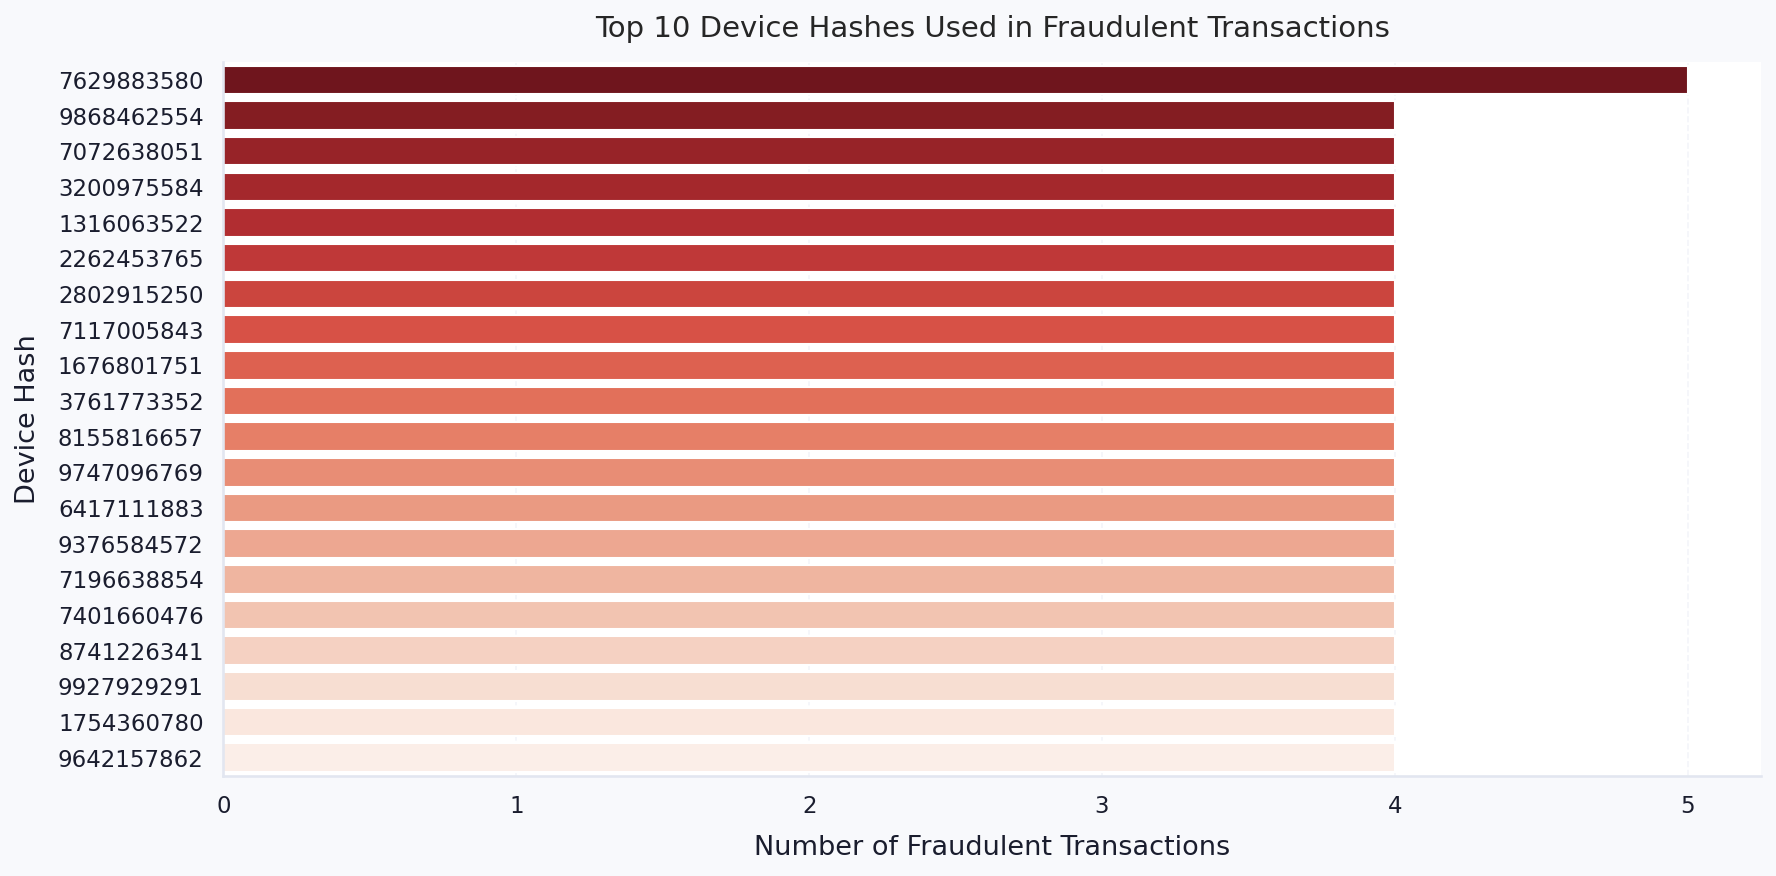

In [8]:
# Filter fraudulent transactions
fraud_devices = df[df["is_fraud"] == 1]

# Count fraudulent transactions by device_hash
top10_devices = (
    fraud_devices["receiver_account"]
    .astype(str)
    .value_counts()
    .head(20)
    .reset_index()
)

top10_devices.columns = ["receiver_account", "fraud_count"]

# Plot
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top10_devices,
    x="fraud_count",
    y="receiver_account",
    palette="Reds_r"
)

plt.title("Top 10 Device Hashes Used in Fraudulent Transactions", fontsize=14)
plt.xlabel("Number of Fraudulent Transactions")
plt.ylabel("Device Hash")
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [13]:
fraud_devices = df[df["is_fraud"] == 1]
receiver_fraud = fraud_devices["receiver_account"]
sender = df[df["receiver_account"].isin(receiver_fraud)]
sender

,is_fraud,fraud_type,transaction_id,timestamp,sender_account,receiver_account,amount_ngn,sender_persona,location,ip_geo_region,...,user_txn_frequency_24h,user_txn_count_total,user_avg_txn_amt,user_std_txn_amt,avg_gap_between_txns,txn_hour,spending_deviation_score,velocity_score,geo_anomaly_score,geospatial_velocity_anomaly
14,0,NaN,T315284,2023-05-26 18:50:42.912482,1000025084,4106538686,3.292260e+06,Salary Earner,Abuja,North Central,...,5,8,999064.875,1.402308e+06,35180.589844,18,-0.36,14,0.51,0
18,1,Account Takeover,T5009180,2023-03-10 12:11:02.165112,1000031378,9331933616,2.220083e+06,Trader,Ibadan,South West,...,1,5,2220083.250,0.000000e+00,0.000000,12,1.65,2,0.79,0
29,0,NaN,T2969299,2023-08-07 16:36:51.106319,1000076996,4071547431,4.786960e+06,Trader,Enugu,South East,...,3,6,2296154.500,2.254133e+06,58669.550781,16,1.58,18,0.08,0
32,1,Account Takeover,T1432371,2023-12-25 13:58:01.932944,1000076996,6075122995,3.217072e+06,Trader,Ibadan,South West,...,6,6,1703922.125,1.945272e+06,62908.304688,13,1.18,6,0.91,0
34,1,Identity Fraud,T3236851,2023-03-20 20:17:48.049754,1000082040,4071417910,1.592400e+05,Trader,Lagos,South West,...,2,6,292319.625,1.882029e+05,45283.140625,20,-2.01,13,0.20,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999985,0,NaN,T1473696,2023-05-13 17:40:13.923314,9999964656,4870673213,6.955829e+06,Trader,Lagos,South West,...,2,4,3987189.750,4.198290e+06,24460.791016,17,0.82,10,0.41,0
4999987,0,NaN,T4982527,2023-07-27 14:22:49.364666,9999964656,3010527808,1.072510e+04,Trader,Kano,North West,...,4,4,1998776.125,3.338702e+06,39181.042969,14,-0.05,1,0.31,0
4999992,1,Account Takeover,T1402464,2023-08-28 03:21:31.693789,9999973159,9030266473,3.988344e+05,Trader,Kaduna,North West,...,5,9,1067098.000,8.897752e+05,60903.828125,3,0.61,5,0.35,0
4999993,0,NaN,T2131306,2023-09-13 10:20:25.965779,9999973159,1847833434,2.240608e+05,Trader,Kaduna,North West,...,6,9,926591.750,8.670709e+05,54663.007812,10,-0.04,14,0.12,0


/tmp/ipykernel_32693/1387385012.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


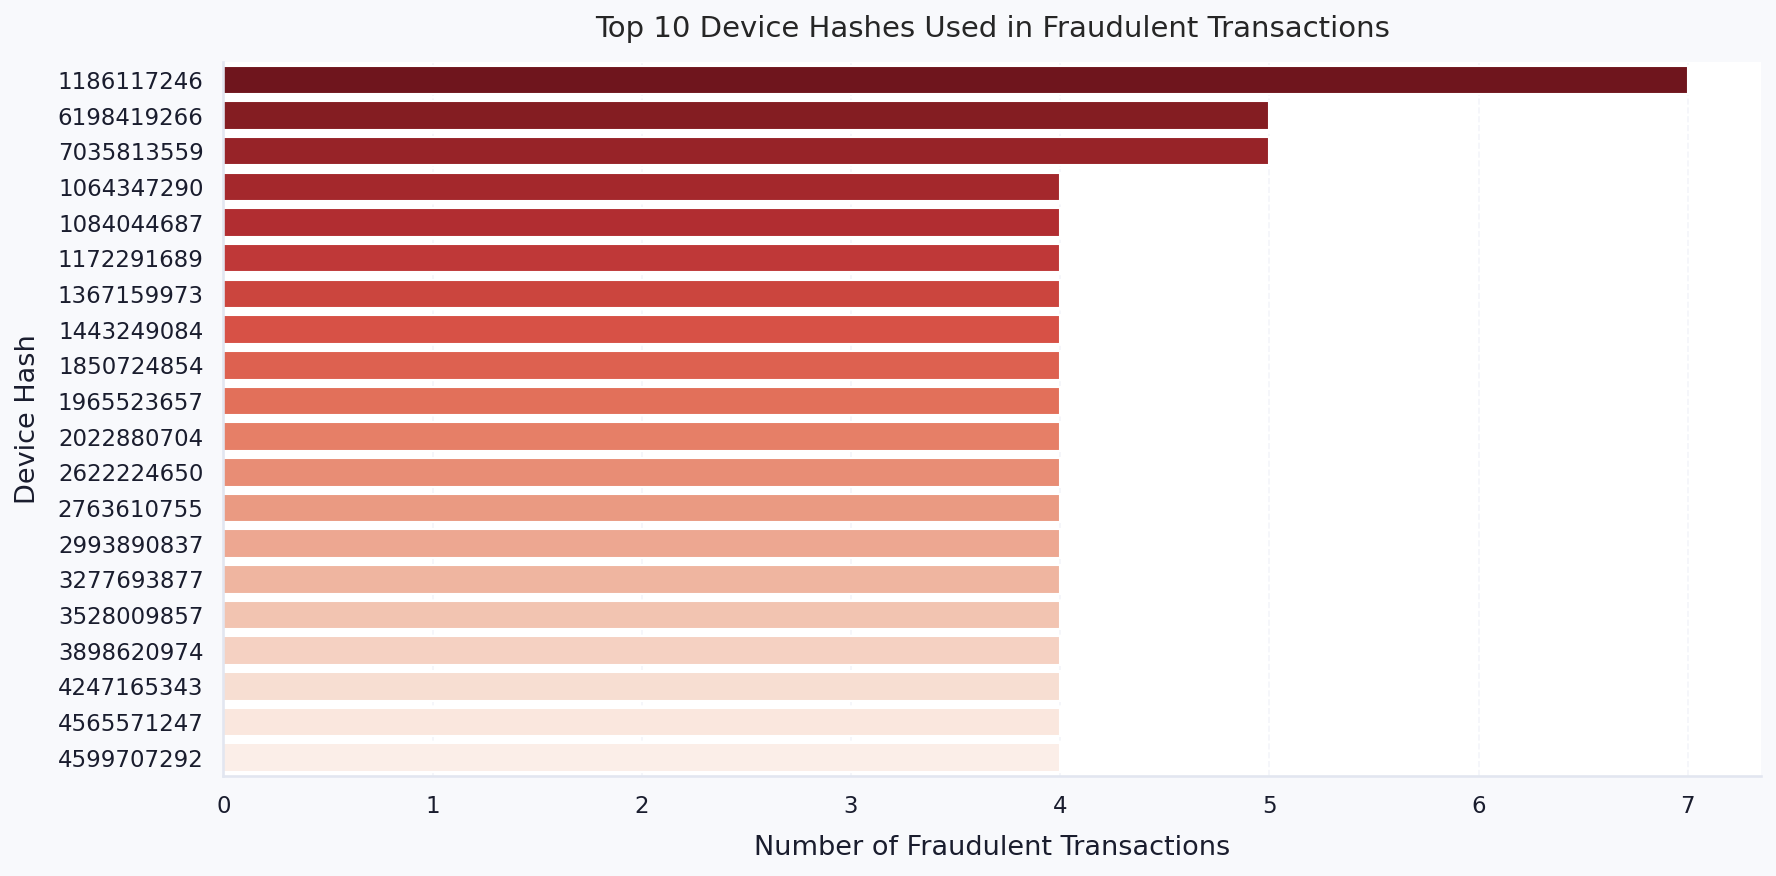

In [18]:
# Filter fraudulent transactions
fraud_account = sender[sender["is_fraud"] == 0]["sender_account"]
fraud_account_transaction = df[df["sender_account"].isin(fraud_account)]
fraud_account_hack = fraud_account_transaction[fraud_account_transaction["is_fraud"] == 1]

# Count fraudulent transactions by device_hash
top10_devices = (
    fraud_account_hack["sender_account"]
    .astype(str)
    .value_counts()
    .head(20)
    .reset_index()
)

top10_devices.columns = ["sender_account", "fraud_count"]

# Plot
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top10_devices,
    x="fraud_count",
    y="sender_account",
    palette="Reds_r"
)

plt.title("Top 10 Device Hashes Used in Fraudulent Transactions", fontsize=14)
plt.xlabel("Number of Fraudulent Transactions")
plt.ylabel("Device Hash")
plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()
